In [4]:
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
import seaborn as sns

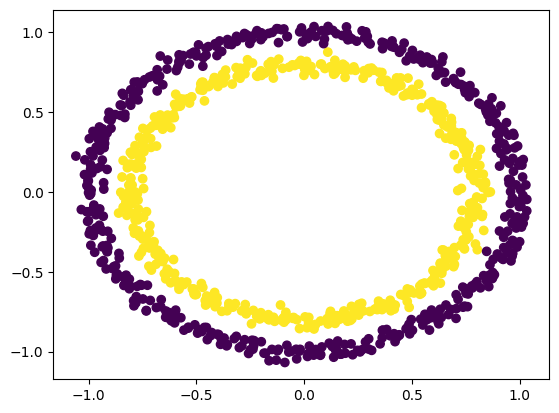

In [5]:

# Generate 1,000 samples with a small amount of noise
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

# Plot the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.show()

In [6]:
model=Sequential()

In [7]:
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
model.add(Dense(5, activation='relu', input_dim=2))
model.add(Dense(5, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [11]:
history=model.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5038 - loss: 0.7037 - val_accuracy: 0.4950 - val_loss: 0.7052
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5025 - loss: 0.7011 - val_accuracy: 0.4500 - val_loss: 0.7038
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5038 - loss: 0.6992 - val_accuracy: 0.4400 - val_loss: 0.7029
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4750 - loss: 0.6980 - val_accuracy: 0.4050 - val_loss: 0.7023
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4663 - loss: 0.6969 - val_accuracy: 0.4300 - val_loss: 0.7018
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4625 - loss: 0.6961 - val_accuracy: 0.4150 - val_loss: 0.7015
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4613 - loss: 0.6955 - val_accuracy: 0.3850 - val_loss: 0.7016
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4588 - loss: 0.6949 - val_accuracy: 0.3850 - 

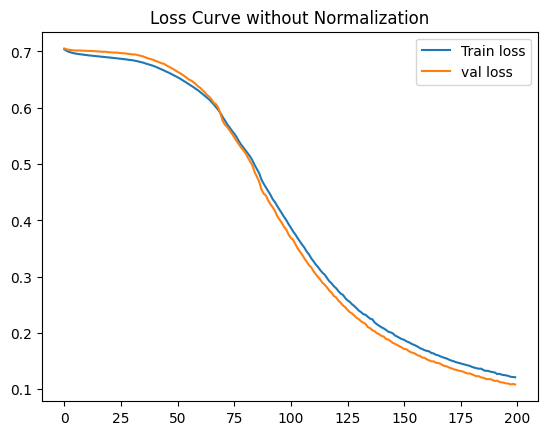

In [12]:
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve without Normalization")
plt.show()

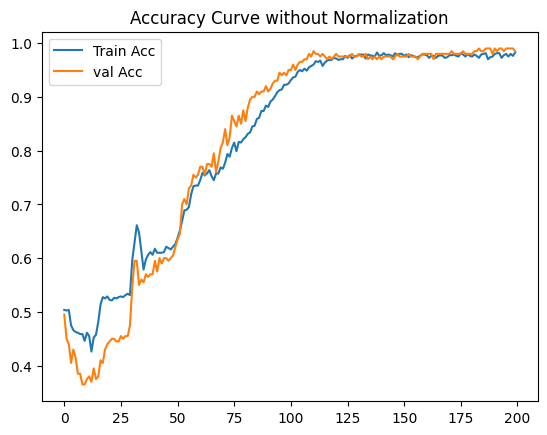

In [13]:
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='val Acc')
plt.legend()
plt.title("Accuracy Curve without Normalization")
plt.show()

In [14]:
model2=Sequential()

In [15]:
model2.add(Dense(5, activation='relu', input_dim=2))
model2.add(BatchNormalization())
model2.add(Dense(5, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dense(1, activation='sigmoid'))

In [16]:
model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 5)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 5)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5)              │            20 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 71 (284.00 B)

 Non-trainable params: 20 (80.00 B)

In [17]:
model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [18]:
history2=model2.fit(X, y, epochs=200, validation_split=0.2)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.4900 - loss: 0.8682 - val_accuracy: 0.4150 - val_loss: 0.7426
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5225 - loss: 0.8090 - val_accuracy: 0.3800 - val_loss: 0.7348
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5425 - loss: 0.7693 - val_accuracy: 0.3900 - val_loss: 0.7277
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5425 - loss: 0.7347 - val_accuracy: 0.4150 - val_loss: 0.7211
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5512 - loss: 0.7123 - val_accuracy: 0.4950 - val_loss: 0.7144
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5888 - loss: 0.6881 - val_accuracy: 0.4500 - val_loss: 0.7118
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6275 - loss: 0.6814 - val_accuracy: 0.4300 - val_loss: 0.7088
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6288 - loss: 0.6741 - val_accuracy: 0.4300 - 

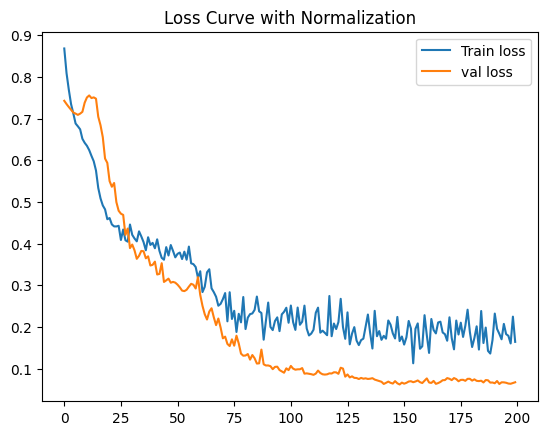

In [19]:
plt.plot(history2.history['loss'], label='Train loss')
plt.plot(history2.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss Curve with Normalization")
plt.show()

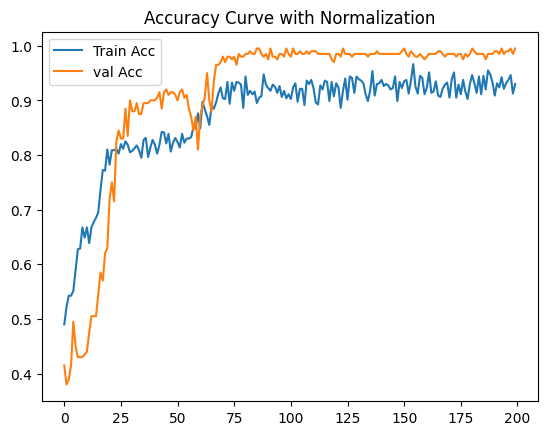

In [20]:
plt.plot(history2.history['accuracy'], label='Train Acc')
plt.plot(history2.history['val_accuracy'], label='val Acc')
plt.legend()
plt.title("Accuracy Curve with Normalization")
plt.show()

# performace Plot

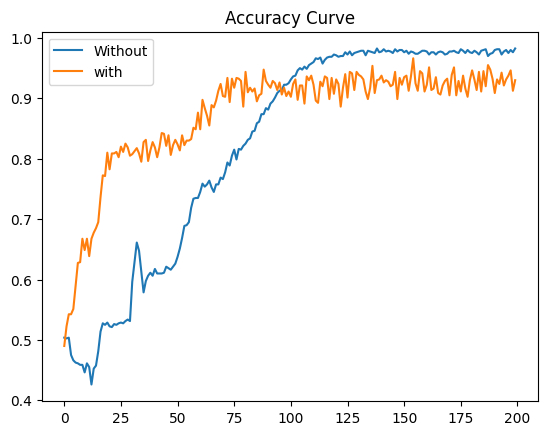

In [21]:
plt.plot(history.history['accuracy'], label='Without')
plt.plot(history2.history['accuracy'], label='with')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

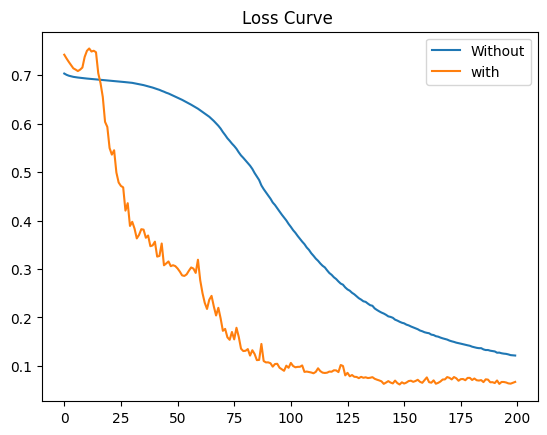

In [22]:
plt.plot(history.history['loss'], label='Without')
plt.plot(history2.history['val_loss'], label='with')
plt.legend()
plt.title("Loss Curve ")
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 711us/step


<Axes: >

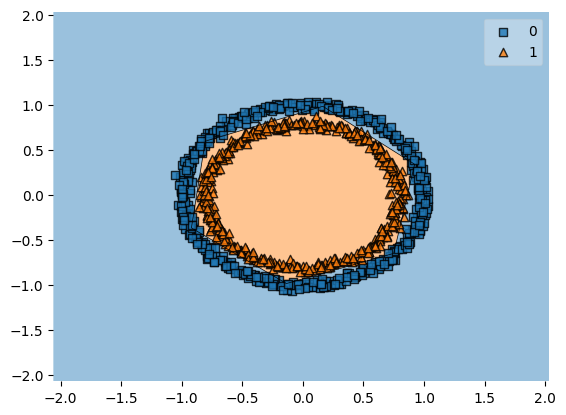

In [23]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y, clf=model)

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 833us/step


<Axes: >

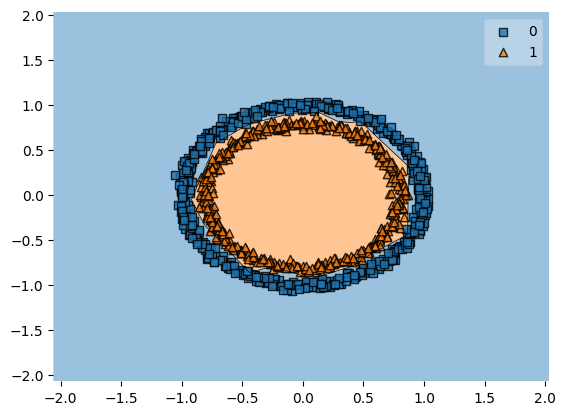

In [24]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y, clf=model2)